# Stage 3 — Total ETF Count Regression (Experiment Notebook)

An interactive, visual companion to `src/train_models.py`, focused **only** on the third stage of the pipeline: predicting **how many ETFs** the investor's portfolio should contain.

This notebook is designed to:

- **Showcase** the full integer-regression workflow end-to-end
- **Let you switch the evaluation metric** with a single variable (`EVAL_METRIC`) — including the integer-specific metrics `exact_match` and `within_1`
- **Let you experiment** with hyperparameters and re-run
- Compare five different regressors on the same data

Nothing is written to disk — the production training script (`src/train_models.py`) owns saved models and reports.

## 1. What this regressor predicts

Given an investor's 19 features (same features as Stages 1 and 2), the model predicts a **single integer**: the total number of ETFs in their portfolio.

| Property | Value |
|---|---|
| Target column | `total_etfs` |
| Valid range | 7 – 13 (integer) |
| Why these bounds | A portfolio with < 7 ETFs is under-diversified; > 13 is over-fragmented (rule from `src/allocations.py`) |

This is **Stage 3** of a 4-stage pipeline:

1. Risk profile classification (see `phase3A_classification_experiments.ipynb`)
2. Asset allocation regression (see `phase3B_allocation_regression_experiments.ipynb`)
3. **(this notebook)** Total ETF count regression
4. Rule-based ETF ticker selection

### Why regression and not classification?

The target *looks* like a class label (one of 7 integer values), but it is **ordinal**: being 1 off is much better than being 6 off. A classifier treats all wrong answers as equally wrong; a regressor naturally penalises a 10→13 miss more than a 10→11 miss. So we keep it as regression and **post-process** the output: round, then clip to `[7, 13]`.

### Naive baselines

- Always predict the training mean → typical MAE ≈ 1.8 (continuous), exact-match ≈ 18%.
- Uniform random over `{7..13}` → exact-match ≈ 1/7 ≈ 14%.
- Any useful model has to comfortably beat both.

## 2. Setup

In [77]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (mean_absolute_error, mean_absolute_percentage_error,
                             mean_squared_error, r2_score, make_scorer)
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

DATA_DIR = '../data/training'
print('Libraries imported.')


Libraries imported.


## 3. Experiment Controls

**This is the only cell you usually need to touch.** Change a value here and re-run all cells below.

| Variable | What it controls |
|---|---|
| `EVAL_METRIC` | Metric used to (a) drive Grid Search and (b) rank models. One of `'mae'`, `'mae_rounded'`, `'rmse'`, `'r2'`, `'exact_match'`, `'within_1'`. |
| `COUNT_RANGE` | Valid integer range. Predictions are clipped to this before computing integer metrics. |
| `CV_FOLDS` | Number of cross-validation folds inside Grid Search. |
| `RANDOM_STATE` | Seed for reproducibility — same seed = same results. |
| `RUN_GRID_SEARCH` | If `False`, models are fit with default hyperparameters (much faster). |
| `PARAM_GRIDS` | The hyperparameter values searched per model. |

### Metric cheat-sheet (integer-regression flavour)

| `EVAL_METRIC` | Lower is better? | What it measures |
|---|---|---|
| `'mae'`         | yes | Mean absolute error on the **raw** continuous prediction |
| `'mae_rounded'` | yes | Mean absolute error **after** `round + clip` post-processing |
| `'rmse'`        | yes | Penalises large misses (e.g. predicting 7 when truth is 13) more than MAE |
| `'r2'`          | **no** — higher is better | Fraction of target variance explained, 0 → 1 |
| `'exact_match'` | **no** — higher is better | Fraction of rounded predictions that are **exactly** right |
| `'within_1'`    | **no** — higher is better | Fraction of rounded predictions within ±1 ETF of the truth |

In [78]:
# ===== EDIT ME =====
EVAL_METRIC     = 'mae_rounded'   # try 'exact_match', 'within_1', 'mae', 'rmse', 'r2'
COUNT_RANGE     = (7, 13)
CV_FOLDS        = 5
RANDOM_STATE    = 42
RUN_GRID_SEARCH = True

# Tree-ensemble grids widened to explore richer hyperparameter space.
# Single-target regression here, so NO 'estimator__' prefix needed.
PARAM_GRIDS = {
    'Linear Regression': {
        # No real hyperparameters to tune — baseline only.
    },
    'Ridge': {
        'alpha': [0.1, 1.0, 10.0, 100.0],   # L2 regularisation strength
    },
    'Random Forest': {
        # 3 × 5 × 4 = 60 combos × 5 folds = 300 fits
        'n_estimators':      [200, 500, 1000],
        'max_depth':         [5, 10, 15, 20, None],
        'min_samples_split': [2, 5, 10, 20],
    },
    'Gradient Boosting': {
        # 3 × 3 × 4 = 36 combos × 5 folds = 180 fits
        'n_estimators':  [100, 200, 500],
        'max_depth':     [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
    },
    'XGBoost': {
        # 3 × 3 × 4 = 36 combos × 5 folds = 180 fits
        'n_estimators':  [200, 500, 1000],
        'max_depth':     [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
    },
}


# --- Post-processing: round + clip ---
# Models output continuous values like 10.37. To compare against integer truth
# we round to the nearest integer and clip to the valid range.
def round_clip(y_pred):
    lo, hi = COUNT_RANGE
    return np.clip(np.round(y_pred), lo, hi).astype(int)


# --- Custom scorer functions for the integer-specific metrics ---
def _mae_rounded_fn(y_true, y_pred):
    return mean_absolute_error(y_true, round_clip(y_pred))

def _exact_match_fn(y_true, y_pred):
    return float((np.asarray(y_true) == round_clip(y_pred)).mean())

def _within_1_fn(y_true, y_pred):
    return float((np.abs(np.asarray(y_true) - round_clip(y_pred)) <= 1).mean())


# Map our friendly metric name to (a) the sklearn scorer GridSearchCV uses and
# (b) whether "lower is better" when ranking the final test-set results.
METRIC_TO_SCORER = {
    'mae':         'neg_mean_absolute_error',
    'rmse':        'neg_root_mean_squared_error',
    'mape':        'neg_mean_absolute_percentage_error',
    'r2':          'r2',
    'mae_rounded': make_scorer(_mae_rounded_fn, greater_is_better=False),
    'exact_match': make_scorer(_exact_match_fn, greater_is_better=True),
    'within_1':    make_scorer(_within_1_fn,    greater_is_better=True),
}
LOWER_IS_BETTER = {
    'mae': True, 'mape': True, 'rmse': True, 'mae_rounded': True,
    'r2': False, 'exact_match': False, 'within_1': False,
}

assert EVAL_METRIC in METRIC_TO_SCORER, \
    f'EVAL_METRIC must be one of {list(METRIC_TO_SCORER)}'

print(f'Evaluation metric:  {EVAL_METRIC}  (lower is better: {LOWER_IS_BETTER[EVAL_METRIC]})')
print(f'Count range:        {COUNT_RANGE}')
print(f'CV folds:           {CV_FOLDS}')
print(f'Random state:       {RANDOM_STATE}')
print(f'Run grid search:    {RUN_GRID_SEARCH}')


Evaluation metric:  mae_rounded  (lower is better: True)
Count range:        (7, 13)
CV folds:           5
Random state:       42
Run grid search:    True


## 4. Load the prepared training data

Features (`X`) and labels (`y_*_etfs`) come from `phase2_data_preparation.ipynb` using the same 80/20 stratified split as Stages 1 and 2.

In [79]:
X_train = pd.read_csv(f'{DATA_DIR}/X_train.csv')
X_test  = pd.read_csv(f'{DATA_DIR}/X_test.csv')

y_train = pd.read_csv(f'{DATA_DIR}/y_train_etfs.csv')['total_etfs']
y_test  = pd.read_csv(f'{DATA_DIR}/y_test_etfs.csv')['total_etfs']

print(f'Train: {X_train.shape[0]:>5} rows  |  Test: {X_test.shape[0]:>5} rows')
print(f'Features: {X_train.shape[1]}   Target: total_etfs  (range {y_train.min()}–{y_train.max()})')
y_train.describe()

Train:  4000 rows  |  Test:  1000 rows
Features: 19   Target: total_etfs  (range 5–16)


count   4000.0000
mean       8.4672
std        1.7541
min        5.0000
25%        7.0000
50%        8.0000
75%        9.0000
max       16.0000
Name: total_etfs, dtype: float64

## 5. Understanding the target

Before any modelling, look at the distribution of ETF counts.

Two things to look for:

1. **Spread.** If everyone has ~10 ETFs, the model has very little to learn — and "always predict 10" would already be a strong baseline.
2. **Skew / mode.** If one count dominates (e.g. 10), then `exact_match` of any model is upper-bounded by how often the mode appears + correctly-classified non-mode rows.

In [80]:
count_table = pd.concat(
    [y_train.value_counts().sort_index().rename('train'),
     y_test.value_counts().sort_index().rename('test')],
    axis=1
).fillna(0).astype(int)
count_table['train_pct'] = 100 * count_table['train'] / count_table['train'].sum()
count_table['test_pct']  = 100 * count_table['test']  / count_table['test'].sum()
count_table

,train,test,train_pct,test_pct
total_etfs,,,,
5,20,9,0.5000,0.9000
6,276,55,6.9000,5.5000
7,964,250,24.1000,25.0000
8,1146,288,28.6500,28.8000
9,743,178,18.5750,17.8000
10,367,106,9.1750,10.6000
11,205,56,5.1250,5.6000
12,139,25,3.4750,2.5000
13,76,16,1.9000,1.6000


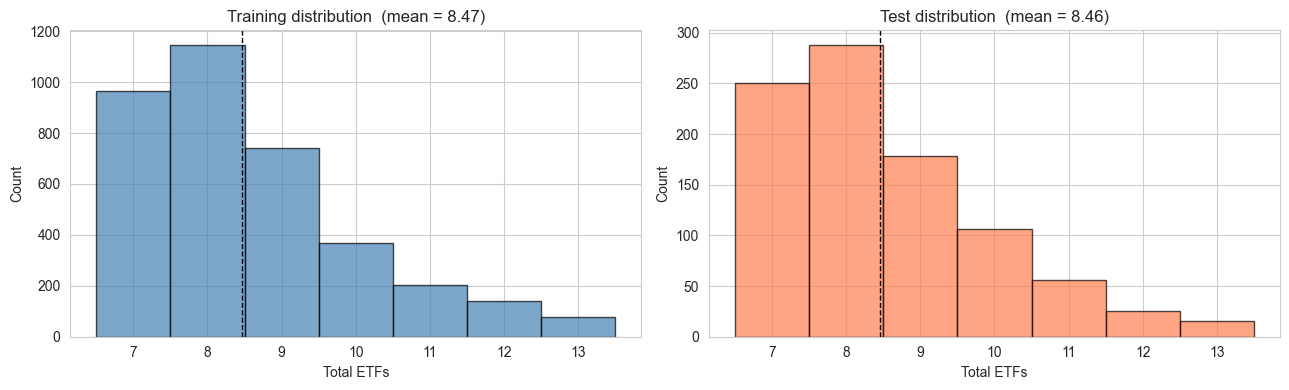

In [81]:
lo, hi = COUNT_RANGE
bins = np.arange(lo - 0.5, hi + 1.5, 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(y_train, bins=bins, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_title(f'Training distribution  (mean = {y_train.mean():.2f})')
axes[0].axvline(y_train.mean(), ls='--', color='black', lw=1)

axes[1].hist(y_test, bins=bins, alpha=0.7, color='coral', edgecolor='black')
axes[1].set_title(f'Test distribution  (mean = {y_test.mean():.2f})')
axes[1].axvline(y_test.mean(), ls='--', color='black', lw=1)

for ax in axes:
    ax.set_xlabel('Total ETFs')
    ax.set_ylabel('Count')
    ax.set_xticks(range(lo, hi + 1))
plt.tight_layout()
plt.show()

## 6. The concepts — quick primer

### 6.1 Why regression for an integer target?

The target is **ordinal**: predicting 10 when the truth is 11 is much better than predicting 7. A classifier loses that ordering — all wrong answers are equally wrong. A regressor preserves it for free in its loss.

After training we **post-process**: `round(prediction)` then `clip(prediction, 7, 13)`. The clip is a guardrail — even a wild prediction stays in the valid range.

### 6.2 Why we don't clip during training

Imagine the model is learning to predict 9 and overshoots to 14. If we clipped the prediction to 13 *before* computing the gradient, the model would never see that it overshot — it would only see "prediction 13, truth 9, error 4" instead of "prediction 14, truth 9, error 5". That distortion would slow down learning. So we clip **only at evaluation time**.

### 6.3 Why we have so many metrics for a 1-target problem

Each metric tells a different story:

| Metric | Story it tells |
|---|---|
| MAE (raw)    | how far off the **continuous** prediction is |
| MAE (rounded)| how far off the **integer** prediction is after round + clip |
| RMSE         | penalises a few big misses heavily — useful when 10→13 is much worse than two 10→11.5 misses |
| R²           | dimensionless: 1.0 perfect, 0.0 = no better than predicting the mean, < 0 = worse than the mean |
| Exact match  | a user-facing metric: "how often is our recommended ETF count exactly right?" |
| Within-1     | a softer user-facing metric: "how often are we within 1 ETF?" |

A model with **MAE_rounded = 1.0** but **exact_match = 18%** means: it's almost always close, almost never exactly right. That tells you the model is biased toward the centre of the distribution (a common failure mode).

### 6.4 How rounding affects MAE

If the raw prediction is 10.4 and truth is 10, the raw error is 0.4. After rounding it becomes 0 — *better*. But if raw is 10.6 and truth is 10, raw error is 0.6 → rounded becomes 11 → error 1.0 — *worse*. So rounding can help or hurt; the comparison table makes both visible.

### 6.5 Grid Search + CV (recap)

Same as Stages 1 and 2 — see `phase3A_classification_experiments.ipynb` section 6 for the long version.

## 7. Helpers

`evaluate_regressor` runs Grid Search (optional), fits, and computes **every** metric — not just the one we're optimising. That way the comparison table later shows you the full picture.

In [82]:
def all_metrics(y_true, y_pred):
    """Compute every metric we care about for a single-target integer regression."""
    y_true_arr = np.asarray(y_true)
    y_pred_r   = round_clip(y_pred)
    return {
        'mae':         mean_absolute_error(y_true_arr, y_pred),
        'mape':        mean_absolute_percentage_error(y_true_arr, y_pred),
        'mae_rounded': mean_absolute_error(y_true_arr, y_pred_r),
        'rmse':        float(np.sqrt(mean_squared_error(y_true_arr, y_pred))),
        'r2':          r2_score(y_true_arr, y_pred),
        'exact_match': float((y_true_arr == y_pred_r).mean()),
        'within_1':    float((np.abs(y_true_arr - y_pred_r) <= 1).mean()),
    }


def evaluate_regressor(name, estimator, param_grid):
    """Run GridSearchCV (or a plain fit) and return a dict of every metric."""
    n_combos = int(np.prod([len(v) for v in param_grid.values()])) if param_grid else 1
    n_fits   = n_combos * CV_FOLDS

    scorer = METRIC_TO_SCORER[EVAL_METRIC]

    if RUN_GRID_SEARCH and param_grid:
        gs = GridSearchCV(estimator, param_grid, cv=CV_FOLDS,
                          scoring=scorer, n_jobs=-1)
        gs.fit(X_train, y_train)
        best_model    = gs.best_estimator_
        best_params   = gs.best_params_
        # Grid Search maximises its scorer. For 'lower-is-better' metrics, sklearn
        # already negated internally, so flip the sign back to natural units.
        best_cv_score = gs.best_score_
        if LOWER_IS_BETTER[EVAL_METRIC]:
            best_cv_score = -best_cv_score
    else:
        estimator.fit(X_train, y_train)
        best_model    = estimator
        best_params   = '(no grid search)'
        best_cv_score = np.nan

    train_pred = best_model.predict(X_train)
    test_pred  = best_model.predict(X_test)

    train_metrics = all_metrics(y_train, train_pred)
    test_metrics  = all_metrics(y_test,  test_pred)

    print(f'  Grid: {n_combos} combos × {CV_FOLDS} folds = {n_fits} fits')
    print(f'  Best params:        {best_params}')
    if not np.isnan(best_cv_score):
        print(f'  Best CV {EVAL_METRIC:<12} {best_cv_score:.4f}')
    print(f'  Train {EVAL_METRIC:<12} {train_metrics[EVAL_METRIC]:.4f}')
    print(f'  Test  {EVAL_METRIC:<12} {test_metrics[EVAL_METRIC]:.4f}')
    print('  Test (all metrics): '
          + '  '.join(f'{m}={test_metrics[m]:.4f}' for m in
                      ['mae', 'mape', 'mae_rounded', 'rmse', 'r2', 'exact_match', 'within_1']))

    return {
        'name':          name,
        'best_params':   best_params,
        'best_cv':       best_cv_score,
        'train_metrics': train_metrics,
        'test_metrics':  test_metrics,
        'test_pred':     test_pred,
        'test_pred_r':   round_clip(test_pred),
        'model':         best_model,
    }


results = {}
print('Helpers ready.')


Helpers ready.


## 8. Train and tune each model

Each cell defines an estimator, picks up its grid from `PARAM_GRIDS`, and hands both to `evaluate_regressor`. Everything is controlled by section 3.

### 8.1 Linear Regression — minimal baseline

Plain OLS. If `total_etfs` is essentially a linear function of the 19 features, LR will already be hard to beat.

In [83]:
print('--- Linear Regression ---')
results['Linear Regression'] = evaluate_regressor(
    'Linear Regression',
    LinearRegression(n_jobs=-1),
    PARAM_GRIDS['Linear Regression'],
)

--- Linear Regression ---
  Grid: 1 combos × 5 folds = 5 fits
  Best params:        (no grid search)
  Train mae_rounded  0.7215
  Test  mae_rounded  0.7460
  Test (all metrics): mae=0.7976  mape=0.0961  mae_rounded=0.7460  rmse=1.0225  r2=0.6488  exact_match=0.3990  within_1=0.8720


### 8.2 Ridge — regularised linear baseline

Linear regression + L2 penalty. `alpha=0` recovers plain LR; very large `alpha` pulls every prediction toward the mean (`≈ 10` here). The grid search finds a middle ground.

In [84]:
print('--- Ridge ---')
results['Ridge'] = evaluate_regressor(
    'Ridge',
    Ridge(random_state=RANDOM_STATE),
    PARAM_GRIDS['Ridge'],
)

--- Ridge ---
  Grid: 4 combos × 5 folds = 20 fits
  Best params:        {'alpha': 10.0}
  Best CV mae_rounded  0.7263
  Train mae_rounded  0.7222
  Test  mae_rounded  0.7480
  Test (all metrics): mae=0.7972  mape=0.0961  mae_rounded=0.7480  rmse=1.0223  r2=0.6489  exact_match=0.3970  within_1=0.8720


### 8.3 Random Forest — bagged decision trees

Strong default for tabular regression. Bonus: produces feature importances we'll plot later. No multi-output wrapper needed (single target).

In [85]:
print('--- Random Forest ---')
results['Random Forest'] = evaluate_regressor(
    'Random Forest',
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    PARAM_GRIDS['Random Forest'],
)

--- Random Forest ---


/Users/avivberkovich/Documents/AI_FINANCIAL_ADVISOR/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/avivberkovich/Documents/AI_FINANCIAL_ADVISOR/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/avivberkovich/Documents/AI_FINANCIAL_ADVISOR/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the jobl

  Grid: 60 combos × 5 folds = 300 fits
  Best params:        {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 1000}
  Best CV mae_rounded  0.5265
  Train mae_rounded  0.5220
  Test  mae_rounded  0.5310
  Test (all metrics): mae=0.5729  mape=0.0701  mae_rounded=0.5310  rmse=0.7882  r2=0.7913  exact_match=0.5350  within_1=0.9380


### 8.4 Gradient Boosting — sequential trees

Each new tree corrects the residuals of the prior ensemble. Usually beats RF on regression with low noise.

In [86]:
print('--- Gradient Boosting ---')
results['Gradient Boosting'] = evaluate_regressor(
    'Gradient Boosting',
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    PARAM_GRIDS['Gradient Boosting'],
)

--- Gradient Boosting ---
  Grid: 36 combos × 5 folds = 180 fits
  Best params:        {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
  Best CV mae_rounded  0.5272
  Train mae_rounded  0.5218
  Test  mae_rounded  0.5310
  Test (all metrics): mae=0.5754  mape=0.0706  mae_rounded=0.5310  rmse=0.7896  r2=0.7906  exact_match=0.5350  within_1=0.9380


### 8.5 XGBoost — production-grade gradient boosting

Same idea as Gradient Boosting but with smarter regularisation, faster training, and stronger defaults. Often the top scorer on tabular regression.

In [87]:
print('--- XGBoost ---')
results['XGBoost'] = evaluate_regressor(
    'XGBoost',
    XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1,
                 objective='reg:squarederror', verbosity=0),
    PARAM_GRIDS['XGBoost'],
)

--- XGBoost ---
  Grid: 36 combos × 5 folds = 180 fits
  Best params:        {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 500}
  Best CV mae_rounded  0.5323
  Train mae_rounded  0.5188
  Test  mae_rounded  0.5300
  Test (all metrics): mae=0.5812  mape=0.0712  mae_rounded=0.5300  rmse=0.7940  r2=0.7882  exact_match=0.5350  within_1=0.9390


## 9. Model comparison

Every metric is computed for every model, regardless of which one Grid Search optimised. The column highlighted in the heatmap is the one used to pick the winner.

In [88]:
METRIC_ORDER = ['mae', 'mape', 'rmse', 'r2']

comparison = pd.DataFrame(
    {name: {**{m: r['test_metrics'][m] for m in METRIC_ORDER},
            'Best Params': str(r['best_params'])}
     for name, r in results.items()}
).T[METRIC_ORDER + ['Best Params']]
comparison.index.name = 'Model'

numeric_cols = METRIC_ORDER

# Per-column gradients: dark = good. Reverse for lower-is-better metrics so
# dark blue still means "best" everywhere.
lower_cols  = [m for m in METRIC_ORDER if LOWER_IS_BETTER[m]]
higher_cols = [m for m in METRIC_ORDER if not LOWER_IS_BETTER[m]]

styled = (comparison.style
          .format({c: '{:.4f}' for c in numeric_cols})
          .background_gradient(subset=lower_cols,  cmap='Blues_r')
          .background_gradient(subset=higher_cols, cmap='Blues'))
styled


,mae,mape,rmse,r2,Best Params
Model,,,,,
Linear Regression,0.7976,0.0961,1.0225,0.6488,(no grid search)
Ridge,0.7972,0.0961,1.0223,0.6489,{'alpha': 10.0}
Random Forest,0.5729,0.0701,0.7882,0.7913,"{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 1000}"
Gradient Boosting,0.5754,0.0706,0.7896,0.7906,"{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}"
XGBoost,0.5812,0.0712,0.7940,0.7882,"{'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 500}"


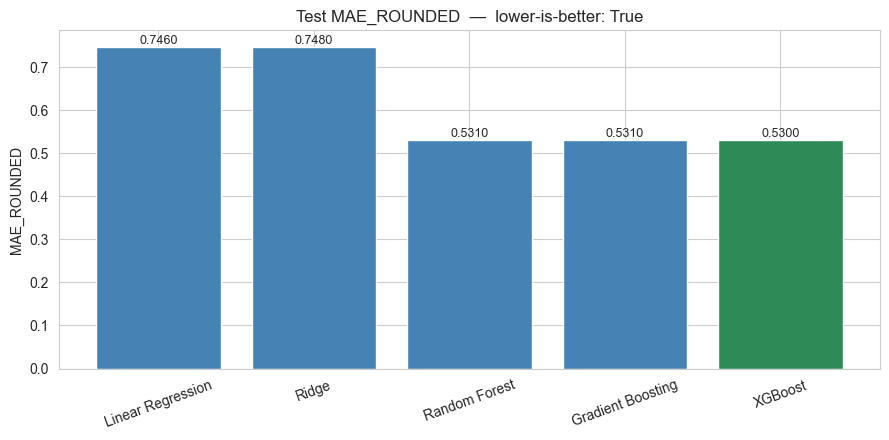

In [89]:
# Bar chart of the chosen metric. Pulled from `results` so it works even when
# EVAL_METRIC is one of the metrics not shown in the comparison table above.
fig, ax = plt.subplots(figsize=(9, 4.5))
scores = pd.Series(
    {name: r['test_metrics'][EVAL_METRIC] for name, r in results.items()},
    name=EVAL_METRIC,
).astype(float)
colors = ['steelblue'] * len(scores)
best_idx = scores.idxmin() if LOWER_IS_BETTER[EVAL_METRIC] else scores.idxmax()
colors[list(scores.index).index(best_idx)] = 'seagreen'

bars = ax.bar(scores.index, scores.values, color=colors)
ax.set_title(f'Test {EVAL_METRIC.upper()}  —  lower-is-better: {LOWER_IS_BETTER[EVAL_METRIC]}')
ax.set_ylabel(EVAL_METRIC.upper())
ax.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, scores.values):
    ax.text(bar.get_x() + bar.get_width()/2, val,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


## 10. Final model selection

The winner is chosen by `EVAL_METRIC`. Switch it in section 3 and re-run — different metrics may pick different winners. That's the whole point of having the knob.

In [90]:
scores = {name: r['test_metrics'][EVAL_METRIC] for name, r in results.items()}
winner_name = (min if LOWER_IS_BETTER[EVAL_METRIC] else max)(scores, key=scores.get)
winner = results[winner_name]

print(f'Optimising for:  {EVAL_METRIC}  (lower better: {LOWER_IS_BETTER[EVAL_METRIC]})')
print(f'WINNER:          {winner_name}')
print(f'  Best params:        {winner["best_params"]}')
print('  Test metrics:       '
      + '  '.join(f'{m}={winner["test_metrics"][m]:.4f}' for m in METRIC_ORDER))

Optimising for:  mae_rounded  (lower better: True)
WINNER:          XGBoost
  Best params:        {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 500}
  Test metrics:       mae=0.5812  mape=0.0712  rmse=0.7940  r2=0.7882


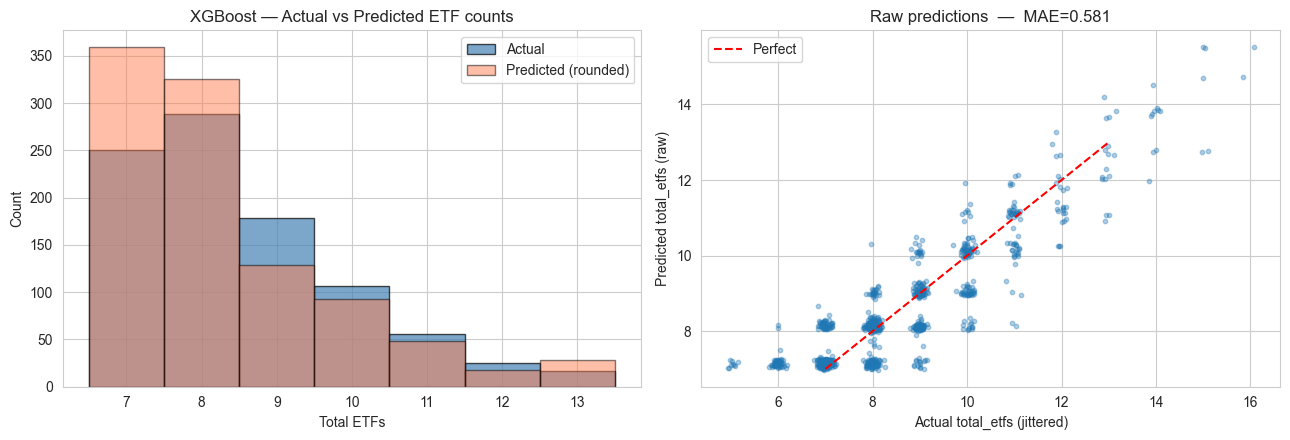

In [91]:
# Predicted vs actual distribution — does the winner reproduce the shape
# of the true distribution, or does it collapse toward the mean?
lo, hi = COUNT_RANGE
bins = np.arange(lo - 0.5, hi + 1.5, 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(y_test, bins=bins, alpha=0.7, color='steelblue', edgecolor='black',
             label='Actual')
axes[0].hist(winner['test_pred_r'], bins=bins, alpha=0.5, color='coral',
             edgecolor='black', label='Predicted (rounded)')
axes[0].set_title(f'{winner_name} — Actual vs Predicted ETF counts')
axes[0].set_xlabel('Total ETFs')
axes[0].set_ylabel('Count')
axes[0].set_xticks(range(lo, hi + 1))
axes[0].legend()

# Predicted (raw) vs actual scatter, with jitter so overlapping points are visible.
rng = np.random.default_rng(RANDOM_STATE)
jitter = rng.normal(0, 0.08, size=len(y_test))
axes[1].scatter(y_test.values + jitter, winner['test_pred'], alpha=0.35, s=10)
axes[1].plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Perfect')
axes[1].set_xlabel('Actual total_etfs (jittered)')
axes[1].set_ylabel('Predicted total_etfs (raw)')
axes[1].set_title(f'Raw predictions  —  MAE={winner["test_metrics"]["mae"]:.3f}')
axes[1].legend()
plt.tight_layout()
plt.show()

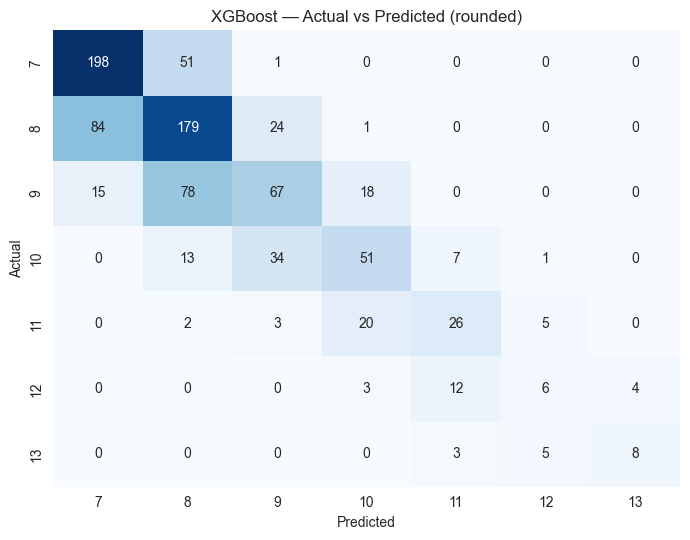

In [92]:
# Confusion-matrix-style heatmap: rows = actual count, cols = predicted rounded count.
# Reads exactly like a classifier's confusion matrix.
lo, hi = COUNT_RANGE
labels = list(range(lo, hi + 1))
cm = pd.crosstab(y_test.rename('Actual'),
                 pd.Series(winner['test_pred_r'], name='Predicted'),
                 dropna=False).reindex(index=labels, columns=labels, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
ax.set_title(f'{winner_name} — Actual vs Predicted (rounded)')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

### Feature importance

Pulled from the Random Forest because it always exposes `feature_importances_` regardless of which model won. Linear/Ridge use coefficients (sign-dependent), XGBoost has its own scheme — we keep RF for a clean, comparable view.

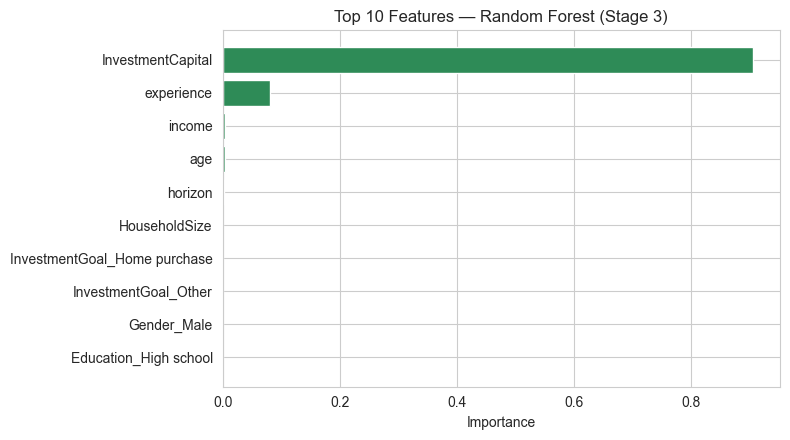

In [93]:
rf_model = results['Random Forest']['model']
fi = (pd.DataFrame({'feature': X_train.columns,
                    'importance': rf_model.feature_importances_})
        .sort_values('importance', ascending=False)
        .head(10))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(fi['feature'][::-1], fi['importance'][::-1], color='seagreen')
ax.set_xlabel('Importance')
ax.set_title('Top 10 Features — Random Forest (Stage 3)')
plt.tight_layout()
plt.show()

## 11. Experiment area

Each prompt below is **one variable change** in section 3, then re-run all cells.

1. **Swap the metric.** Try `EVAL_METRIC = 'mae_rounded'` → `'exact_match'` → `'within_1'`. The `exact_match` winner is sometimes a *different* model than the MAE winner — a model with rounded MAE 1.1 can have a higher exact-match rate than a model with MAE 1.05 if its errors are more concentrated on "close but wrong" cases.
2. **Raw vs rounded MAE.** Compare `'mae'` vs `'mae_rounded'` columns in the table. When are they close, and when does rounding noticeably hurt?
3. **Beat the mean.** In a scratch cell below, predict `round(y_train.mean())` for every test row. Compute MAE, exact_match, within_1. That's the floor.
4. **Turn off Grid Search.** Set `RUN_GRID_SEARCH = False`. How much does tuning buy you on this stage compared to Stages 1 and 2?
5. **Shrink the forest.** Set `'max_depth': [3, 5]` in `PARAM_GRIDS['Random Forest']`. Does the RF underfit on a target this simple?
6. **Per-class performance.** In a scratch cell, compute exact_match **separately for each true count value**. Is the model much better at predicting the mode than the tails?
7. **Tighten or loosen the bounds.** Change `COUNT_RANGE = (8, 12)`. Predictions clip into a narrower band — does exact_match go up artificially?

Use the empty cells below to try things out without scrolling back up.

In [94]:
# Scratch cell — try things here


In [95]:
# Scratch cell — try things here
